In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
# Load datasets
household_df = pd.read_csv("Household_Data(in).csv")
vehicle_df = pd.read_csv("Vehicle_Data(in).csv")

# Merge datasets on a common column
merged_df = pd.merge(household_df, vehicle_df, on="household_id")

# Preview data
print(merged_df.head())

  census_division_x census_region_x  driver_count    household_income  \
0       New England       Northeast             2    $175,000 or more   
1       New England       Northeast             2    $175,000 or more   
2       New England       Northeast             2  $75,000 to $99,999   
3       New England       Northeast             2  $75,000 to $99,999   
4       New England       Northeast             1    $175,000 or more   

   household_size                           home_type  number_adults_hh  \
0               4                 One-family detached                 2   
1               4                 One-family detached                 2   
2               2  Building with 2 or more apartments                 2   
3               4  Building with 2 or more apartments                 2   
4               1                     Townhome, Condo                 1   

   vehicles_per_household  travel_date_x travel_day_x  ... travel_day_y  \
0                       2         2

In [13]:
# Load dataset
df = pd.read_csv("Vehicle_Data(in).csv")

# Check column names
print(df.columns)


Index(['household_id', 'census_division', 'census_region', 'hybrid', 'make',
       'travel_date', 'travel_day', 'urban', 'household_location',
       'vehicle_age', 'vehicle_commercial', 'vehicle_delivery',
       'vehicle_rideshare', 'fuel_type', 'vehicle_type', 'vehicle_year'],
      dtype='str')


In [14]:
# ---- Count trips by census_region ----
# Each row is assumed to represent a trip
trip_counts = merged_df['census_region_x'].value_counts().reset_index()
trip_counts.columns = ['census_region_x', 'trip_count']

print(trip_counts)

  census_region_x  trip_count
0           South        5349
1         Midwest        3707
2            West        3371
3       Northeast        2257


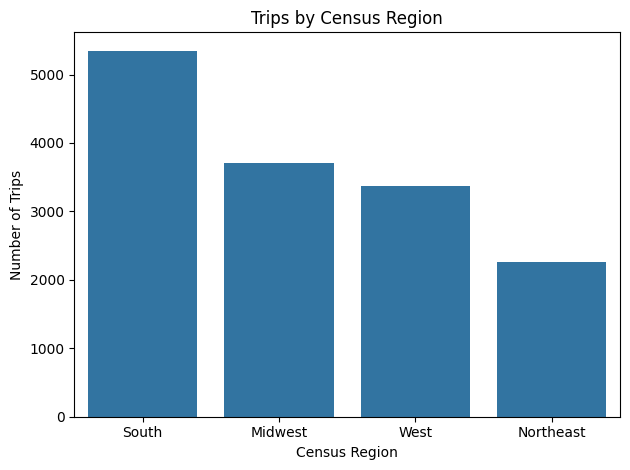

In [15]:
# ---- Plot ----
plt.figure()
sns.barplot(data=trip_counts, x='census_region_x', y='trip_count')

plt.xlabel("Census Region")
plt.ylabel("Number of Trips")
plt.title("Trips by Census Region")

plt.tight_layout()
plt.show()

In [23]:
# Count trips per household
trip_counts = vehicle_df.groupby("household_id").size().reset_index(name="num_trips")

merged_df = pd.merge(household_df, trip_counts, on="household_id", how="left")

# Replace NaN (households with no trips) with 0
merged_df["num_trips"] = merged_df["num_trips"].fillna(0)


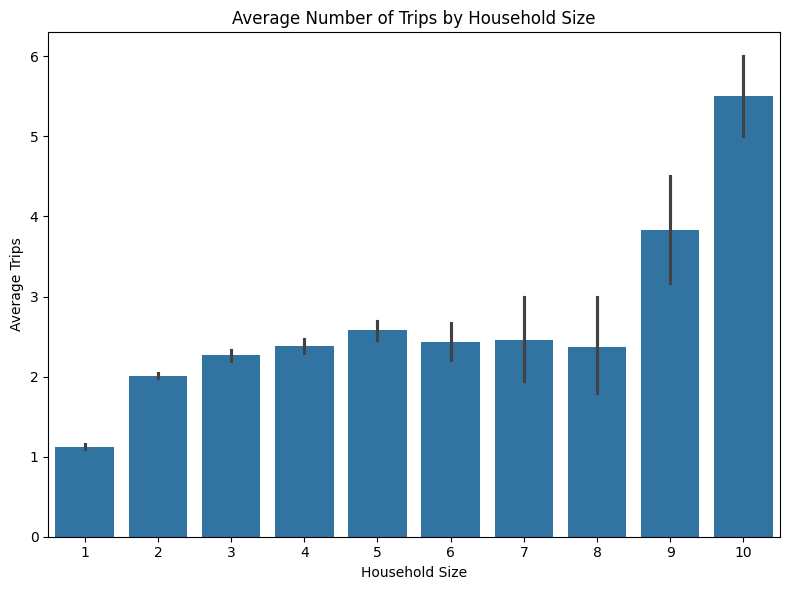

In [24]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=merged_df,
    x="household_size",
    y="num_trips"
)

plt.title("Average Number of Trips by Household Size")
plt.xlabel("Household Size")
plt.ylabel("Average Trips")

plt.tight_layout()
plt.show()

In [30]:
# Merge datasets on a common column
merged_df = pd.merge(household_df, vehicle_df, on="household_id")

# Count transportation types per income level
grouped = merged_df.groupby(["household_income", "vehicle_type"]).size().reset_index(name="count")


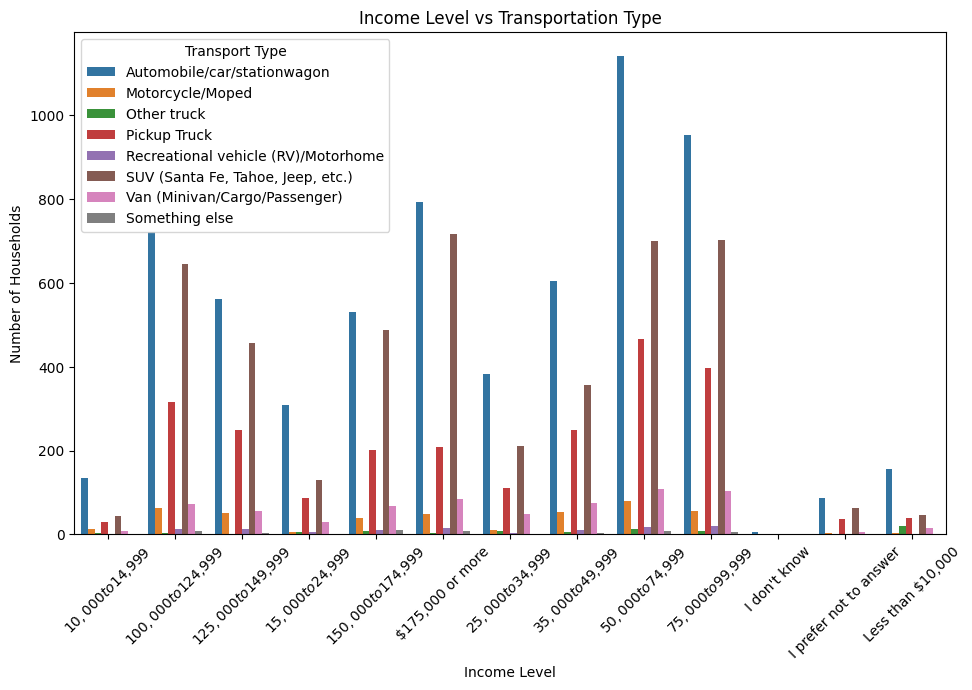

In [31]:
# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=grouped, x="household_income", y="count", hue="vehicle_type")

plt.title("Income Level vs Transportation Type")
plt.xlabel("Income Level")
plt.ylabel("Number of Households")
plt.legend(title="Transport Type")
plt.tight_layout()

plt.xticks(rotation=45)

plt.show()